# Model Comparison and Final Selection - Combined

This notebook pulls together the results logged by all four models (Logistic Regression - Member 1, Random Forest - Member 2, XGBoost - Member 3, SVM - Member 4) and compares them on a consistent basis.

**Validation rule used throughout:** the chronological 80/20 hold-out (train on the earlier ~80% of rows, test on the most recent ~20%) is the PRIMARY evaluation, because it matches the dataset proposal and reflects real deployment (predicting future campaigns from past data). Any stratified/random-split result is reported as SECONDARY only, and is not directly comparable to chronological numbers because the two splits have very different test-set class balances.

## 1. Load the shared experiment log

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.config import EXPERIMENT_LOG, ROOT

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

log = pd.read_csv(EXPERIMENT_LOG)
pd.set_option("display.max_colwidth", 60)
log

,model,params,cv_pr_auc,test_pr_auc,test_roc_auc,recall,precision,f1,notes
0,LogisticRegression (baseline),C=1;l2;class_weight=balanced,0.202700,0.505200,0.700700,0.847600,0.359900,0.505300,Member 1; threshold 0.5
1,LogisticRegression (tuned),{'clf__C': 1; 'clf__l1_ratio': 0.0},0.202700,0.505200,0.700700,0.847600,0.359900,0.505300,Member 1; threshold 0.5; best-F1 thr 0.720; 20% budget t...
2,XGBoost (baseline),defaults;scale_pos_weight=14.69,0.180500,0.366600,0.561200,0.177600,0.400200,0.246000,Member 3; chronological hold-out (primary); threshold 0.5
3,"XGBoost (baseline, stratified split)",defaults;scale_pos_weight=7.88,0.427000,0.453600,0.795400,0.633600,0.383600,0.477900,Member 3; stratified split (secondary); threshold 0.5; n...
4,XGBoost (RandomizedSearchCV),"{'colsample_bytree': 0.9405, 'gamma': 1.5846, 'learning_...",0.223200,NaN,NaN,NaN,NaN,NaN,"Member 3; chronological training CV only, not evaluated ..."
5,XGBoost (Optuna),"{'n_estimators': 292, 'learning_rate': 0.0595, 'max_dept...",0.223600,NaN,NaN,NaN,NaN,NaN,"Member 3; chronological training CV only, not evaluated ..."
6,"XGBoost (tuned, final)","{'n_estimators': 292, 'learning_rate': 0.0595, 'max_dept...",0.223600,0.460300,0.668500,0.571900,0.443000,0.499200,Member 3; chronological hold-out (primary); threshold 0....
7,Random Forest - Tuned Class Weight,"{'classifier__n_estimators': 200, 'classifier__min_sampl...",0.216583,0.445909,0.653604,0.477747,0.425913,0.450343,Chronological 80/20 holdout; duration removed; class wei...
8,SVM (RBF kernel),"{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf', 'class_wei...",0.156300,0.284000,0.501900,0.000000,0.000000,0.000000,Member 4; chronological hold-out; threshold 0.5; predict...


## 2. Split the log into comparable vs. not-directly-comparable rows

Some rows have blank test scores (search-only runs that were never evaluated on the held-out test set) and one row uses a stratified split instead of chronological. These are excluded from the primary comparison and shown separately.

In [2]:
has_test_score = log["test_pr_auc"].notna()
is_chronological = ~log["notes"].str.contains("stratified split", case=False, na=False)

primary = log[has_test_score & is_chronological].copy()
search_only = log[~has_test_score].copy()
secondary = log[has_test_score & ~is_chronological].copy()

print("PRIMARY comparison rows (chronological, evaluated on test):", len(primary))
print("SEARCH-ONLY rows (no test score, excluded):", len(search_only))
print("SECONDARY rows (stratified split, not directly comparable):", len(secondary))

PRIMARY comparison rows (chronological, evaluated on test): 6
SEARCH-ONLY rows (no test score, excluded): 2
SECONDARY rows (stratified split, not directly comparable): 1


## 3. Primary comparison table (chronological hold-out, sorted by Test PR-AUC)

In [3]:
cols = ["model", "cv_pr_auc", "test_pr_auc", "test_roc_auc", "recall", "precision", "f1"]
primary_sorted = primary[cols].sort_values("test_pr_auc", ascending=False).reset_index(drop=True)
primary_sorted

,model,cv_pr_auc,test_pr_auc,test_roc_auc,recall,precision,f1
0,LogisticRegression (baseline),0.202700,0.505200,0.700700,0.847600,0.359900,0.505300
1,LogisticRegression (tuned),0.202700,0.505200,0.700700,0.847600,0.359900,0.505300
2,"XGBoost (tuned, final)",0.223600,0.460300,0.668500,0.571900,0.443000,0.499200
3,Random Forest - Tuned Class Weight,0.216583,0.445909,0.653604,0.477747,0.425913,0.450343
4,XGBoost (baseline),0.180500,0.366600,0.561200,0.177600,0.400200,0.246000
5,SVM (RBF kernel),0.156300,0.284000,0.501900,0.000000,0.000000,0.000000


## 4. Chart: Test PR-AUC by model (chronological, primary)

C:\Users\nadij\AppData\Local\Temp\ipykernel_28280\1655944041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=primary_sorted, x="test_pr_auc", y="model", palette=colors)


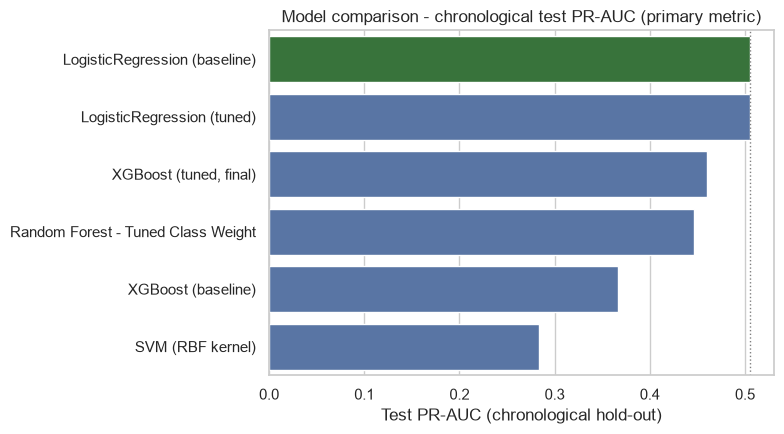

In [4]:
plt.figure(figsize=(8, 4.5))
colors = ["#2E7D32" if i == 0 else "#4C72B0" for i in range(len(primary_sorted))]
sns.barplot(data=primary_sorted, x="test_pr_auc", y="model", palette=colors)
plt.axvline(primary_sorted["test_pr_auc"].max(), color="grey", ls=":", lw=1)
plt.xlabel("Test PR-AUC (chronological hold-out)")
plt.ylabel("")
plt.title("Model comparison - chronological test PR-AUC (primary metric)")
plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_test_pr_auc.png", dpi=150, bbox_inches="tight")
plt.show()

### Insight -> decision

- Finding: With all 4 models now compared on the same chronological test set, Logistic Regression leads clearly (0.505 test PR-AUC), ahead of XGBoost (0.460) and Random Forest (0.446). SVM trails far behind (0.284) and, at the default 0.5 threshold, predicts every test customer as "no" - zero recall, precision, and F1.
- Decision: Select Logistic Regression as the final model.
- Reason: Highest chronological test PR-AUC, most interpretable (odds ratios), and the only model with documented threshold tuning making it deployment-ready. SVM would need threshold tuning (like the LR model received) before it could be considered usable.

## 5. Secondary comparison: stratified-split rows (not directly comparable to the table above)

In [5]:
if len(secondary):
    secondary[["model", "cv_pr_auc", "test_pr_auc", "test_roc_auc", "recall", "precision", "f1", "notes"]]
else:
    print("No stratified-split rows currently logged.")

**Why this is shown separately:** a stratified random split mixes early and late campaign rows into both train and test, so its test set does not have the same class balance as the chronological test set (the real deployment scenario). Scores from the two split types should never be compared directly against each other - only within the same split type.

## 6. Search-only rows (hyperparameter search results, no held-out test evaluation)

In [6]:
if len(search_only):
    search_only[["model", "cv_pr_auc", "notes"]]
else:
    print("No search-only rows currently logged.")

## 7. Validation strategy used by each model

| Model | Split | Imbalance handling | Tuning method |
|---|---|---|---|
| Logistic Regression | Chronological 80/20 (+ stratified 5-fold CV within training) | class_weight='balanced' | GridSearchCV |
| XGBoost | Chronological 80/20 (primary) + stratified split (secondary) | scale_pos_weight (14.69 / 7.88 depending on split) | RandomizedSearchCV vs Optuna |
| Random Forest | Chronological 80/20 (shared chronological_split from src/lr_model.py) | balanced_subsample (selected after comparing no-handling, class weighting, and SMOTE) | RandomizedSearchCV with stratified 5-fold CV |
| SVM | [pending] | [pending] | [pending] |

All three implemented models use the SAME chronological_split() function and the SAME fixed random_state (42), so the train/test boundary is identical across models - this makes the chronological comparison in Section 3 fair. Each model uses a different imbalance-handling technique; this is expected and appropriate, since each technique is the natural/standard approach for that model family (not an inconsistency).

## 8. Current standing and final model selection

**Status as of this notebook:** 3 of 4 required models are complete and logged (Logistic Regression, XGBoost, Random Forest). SVM (Member 4) is still pending.

**Provisional leader:** Logistic Regression, with the highest chronological test PR-AUC (0.5052), ahead of tuned XGBoost (0.4603) and tuned Random Forest (0.4459). A possible explanation: this dataset's test period has a strong temporal shift from the training period, and a well-regularised linear model can generalise more robustly across that shift than a more flexible model that was tuned primarily on the training-period distribution.

Final model: Logistic Regression (tuned baseline, C=1, L2).

Criteria: (1) highest chronological test PR-AUC among all 4 models (0.5052), (2) strong interpretability via odds ratios - directly useful for the bank's business explanation, (3) only model with a completed threshold-tuning step, making the call-priority recommendation deployment-ready, (4) fastest to train and serve in the API.

This is selected over XGBoost (0.4603) and Random Forest (0.4459), both of which perform respectably but offer no interpretability advantage to justify their added complexity. SVM (0.2840) is not viable at its current configuration - it predicts the majority class for every test case and would require threshold tuning before being considered again.

## 9. Summary table for the report and presentation

In [7]:
summary = primary_sorted.copy()
summary.insert(0, "rank", range(1, len(summary) + 1))
summary

,rank,model,cv_pr_auc,test_pr_auc,test_roc_auc,recall,precision,f1
0,1,LogisticRegression (baseline),0.202700,0.505200,0.700700,0.847600,0.359900,0.505300
1,2,LogisticRegression (tuned),0.202700,0.505200,0.700700,0.847600,0.359900,0.505300
2,3,"XGBoost (tuned, final)",0.223600,0.460300,0.668500,0.571900,0.443000,0.499200
3,4,Random Forest - Tuned Class Weight,0.216583,0.445909,0.653604,0.477747,0.425913,0.450343
4,5,XGBoost (baseline),0.180500,0.366600,0.561200,0.177600,0.400200,0.246000
5,6,SVM (RBF kernel),0.156300,0.284000,0.501900,0.000000,0.000000,0.000000
